## Extra Credit -- Larger Dataset (ImageNette)

### Data Setup

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import random

from torchvision.datasets import ImageFolder

import matplotlib.pyplot as plt

def rotate_img(img, rot):
    if rot == 0: # 0 degrees rotation
        return img
    # Implement rotate_img() - return the rotated img
    elif rot == 1 or rot == 2 or rot == 3: # 90, 180, 270 degrees rotation
        return transforms.functional.rotate(img, rot*90)
    else:
        raise ValueError('rotation should be 0, 90, 180, or 270 degrees')
    

class ImageNetteRotation(ImageFolder):
    def __init__(self, root, transform=None):
        super().__init__(root=root, transform=transform)

    def __getitem__(self, index: int):
        image, _ = super().__getitem__(index)

        # randomly select image rotation
        rotation_label = random.choice([0, 1, 2, 3])
        image_rotated = rotate_img(image, rotation_label)

        rotation_label = torch.tensor(rotation_label).long()

        return image_rotated, rotation_label


In [6]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

transform_train = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

transform_val = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

Imagenette_train_dataset = ImageNetteRotation("data/imagenette2/train", transform=transform_train)
Imagenette_val_dataset = ImageNetteRotation("data/imagenette2/val", transform=transform_val)
print(len(Imagenette_train_dataset))
print(len(Imagenette_val_dataset))

batch_size = 32

Imagenette_train_loader = DataLoader(Imagenette_train_dataset, batch_size=batch_size, shuffle=True)
Imagenette_val_loader = DataLoader(Imagenette_val_dataset, batch_size=batch_size)

9469
3925


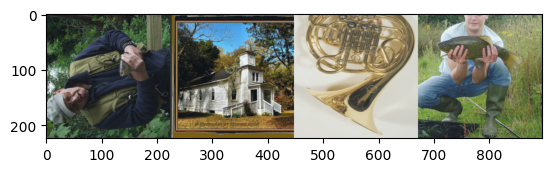

Rotation labels:  90    0     180   0    


In [7]:
rot_classes = ('0', '90', '180', '270')


def imshow(img):
    # unnormalize
    img = transforms.Normalize((0, 0, 0), (1/0.2023, 1/0.1994, 1/0.2010))(img)
    img = transforms.Normalize((-0.4914, -0.4822, -0.4465), (1, 1, 1))(img)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


dataiter = iter(Imagenette_train_loader)
rot_images, rot_labels = next(dataiter)

# print images and rotated images
img_grid = imshow(torchvision.utils.make_grid(rot_images[:4], padding=0))
print('Rotation labels: ', ' '.join(f'{rot_classes[rot_labels[j]]:5s}' for j in range(4)))

### Evaluation Code

In [8]:
# Determine GPU or CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [9]:
import time

def imagenette_run_test(net, testloader, criterion):
    correct = 0
    total = 0
    avg_test_loss = 0.0
    # since we're not training, we don't need to calculate the gradients for our outputs
    with torch.no_grad():
        for images_rotated, labels in testloader:
            images, labels = images_rotated.to(device), labels.to(device)
            # Calculate outputs by running images through the network
            # The class with the highest energy is what we choose as prediction
            outputs = net(images)
            # Choose the class with the highest energy
            prediction = torch.argmax(outputs, dim=1)
            
            # Update the parameters for calculating the accuracy
            total += labels.size(0)
            correct += (prediction == labels).sum().item()
            
            # loss
            avg_test_loss += criterion(outputs, labels)  / len(testloader)
    print('TESTING:')
    print(f'Accuracy of the network on the 10000 test images: {100 * correct / total:.2f} %')
    print(f'Average loss on the 10000 test images: {avg_test_loss:.3f}')

In [10]:
def adjust_learning_rate(optimizer, epoch, init_lr, decay_epochs=30):
    """Sets the learning rate to the initial LR decayed by 10 every 30 epochs"""
    lr = init_lr * (0.1 ** (epoch // decay_epochs))
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

### Train model on rotation task

In [11]:
# Determine GPU or CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [16]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

net = resnet18(num_classes=4)
net.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(512, 4)
)

net = net.to(device)
print(net)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [17]:
import torch.optim as optim

# Define criterion and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(net.parameters(), weight_decay=1e-4)

In [18]:
def imagenette_train(net, criterion, optimizer, num_epochs, decay_epochs, init_lr):

    # Set the initial learning rate
    for param_group in optimizer.param_groups:
        param_group['lr'] = init_lr

    for epoch in range(num_epochs):  # loop over the dataset multiple times

        running_loss = 0.0
        running_correct = 0.0
        running_total = 0.0
        start_time = time.time()

        net.train()

        for i, (imgs_rotated, rotation_label) in enumerate(Imagenette_train_loader, 0):
            adjust_learning_rate(optimizer, epoch, init_lr, decay_epochs)

            # Set the data to the correct device; Different task will use different inputs and labels
            images, labels = imgs_rotated.to(device), rotation_label.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = net(images)
            # the "outputs" is raw logits without softmax, so directly give it to CrossEntropyLoss() function
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # Get predicted results
            predicted = torch.argmax(outputs, dim=1)

            # print statistics
            print_freq = 100
            running_loss += loss.item()

            # calc acc
            running_total += labels.size(0)
            running_correct += (predicted == labels).sum().item()

            if i % print_freq == (print_freq - 1):    # print every 2000 mini-batches
                print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / print_freq:.3f} acc: {100*running_correct / running_total:.2f} time: {time.time() - start_time:.2f}')
                running_loss, running_correct, running_total = 0.0, 0.0, 0.0
                start_time = time.time()

        # Run the test function after each epoch; Set the model to the evaluation mode.
        net.eval()
        imagenette_run_test(net, Imagenette_val_loader, criterion)

    print('Finished Training')

In [19]:
imagenette_train(net, criterion, optimizer, num_epochs=45, decay_epochs=15, init_lr=0.001)

[1,   100] loss: 1.536 acc: 27.22 time: 19.40
[1,   200] loss: 1.422 acc: 28.91 time: 19.34
TESTING:
Accuracy of the network on the 10000 test images: 39.82 %
Average loss on the 10000 test images: 1.312
[2,   100] loss: 1.330 acc: 39.56 time: 19.24
[2,   200] loss: 1.305 acc: 41.09 time: 19.24
TESTING:
Accuracy of the network on the 10000 test images: 40.82 %
Average loss on the 10000 test images: 1.383
[3,   100] loss: 1.279 acc: 41.59 time: 19.10
[3,   200] loss: 1.246 acc: 42.88 time: 19.23
TESTING:
Accuracy of the network on the 10000 test images: 43.54 %
Average loss on the 10000 test images: 1.226
[4,   100] loss: 1.236 acc: 42.91 time: 19.09
[4,   200] loss: 1.225 acc: 44.22 time: 19.08
TESTING:
Accuracy of the network on the 10000 test images: 39.82 %
Average loss on the 10000 test images: 1.284
[5,   100] loss: 1.221 acc: 44.62 time: 19.37
[5,   200] loss: 1.193 acc: 45.91 time: 19.02
TESTING:
Accuracy of the network on the 10000 test images: 46.78 %
Average loss on the 10000